# Greedy Addition For Correct Nodes

In [2]:
# these warnings are fine. you can ignore them.
import random, math
from CriticalNodes import CriticalEdge, CriticalEdges
import pickle

import sys
sys.path.append('../')
from CriticalNodes import CriticalEdge, CriticalEdges
sys.path.append('../../')
from util import *



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [3]:
max_rate = 0.1

In [9]:
### realistically, this should be the only function changing in your guys' notebooks
def checkCorrectClass(i, j, graph, threshold=1):
    return abs(graph.degree[i] - graph.degree[j]) <= threshold

## Setting Up Dataset/Model/Ground Truth

In [10]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=True)
print(ground_truth)

0.745


In [11]:
labels = data.y

## Experiments

**Note:** The ground truth here is $0.745$

In [12]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

homophilies = [0] * len(G.nodes())
degrees = [0] * len(G.nodes())
two_hop_neighborhood_sizes = [0] * len(G.nodes())

for n in G.nodes():
    homophilies[n] = get_node_homophily(G, n, y, y[n].item())
    degrees[n] = G.degree(n)
    two_hop_neighborhood_sizes[n] = nx.ego_graph(G, n, 2).number_of_nodes()

In [14]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()

for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, G):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

568322
CPU times: user 8.01 s, sys: 21 ms, total: 8.03 s
Wall time: 8.05 s


In [15]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
change = 0.000
results_cora = []
for ptb in ptb_rate:
    critical_edges = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=True)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1
        else:
            critical_edges.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_cora.append(loc / budget)

    complete_edges = CriticalEdges(critical_edges)
    complete_edges.print_statistics()
    with open(f'./critical-edges/degree/cora/critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges, file)
    
    print(results_cora)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
200  iterations!
250  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
Miss Rate:  0.09931506849315064
----
Average Degree: 4.758620689655173
Min Degree: 2.0
Max Degree: 10.0
Min Homophily: 0.5
Max Homophily: 1.0
Average Homophily: 0.8359195402298851
Min Two-hop Neighborhood Size: 2.0
Max Two-hop Neighborhood Size: 46.5
Average Two-hop Neighborhood Size: 16.724137931034484
Ground Truth Classification Counts: [6, 1, 0, 11, 6, 4, 1]
----
Edge between nodes:
	Node: 1400
		Homophily: 1.0
		Degree: 4
		Ground Truth: 3
		Two-hop Neighborhood Size: 5
	Node: 2320
		Homophily: 0.5
		Degree: 4
		Ground Truth: 3
		Two-hop Neighborhood Size: 15

Edge between nodes:
	Node: 1021
		Homophily: 0.0
		Degree: 2
		Ground Truth: 4
		Two-hop Neighborhood Size: 9
	Node: 1696
		Homophily: 1.0
		Degree: 2
		Ground Truth: 0
		Two-hop Neighborhood Size: 5

Edge be

# Cora_ML

In [16]:
dataset = Dataset(root='/tmp/Cora_ML', name='Cora_ML', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../', in_feats, h_feats, num_classes, "cora_ml", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=True)
print(ground_truth)

labels = data.y

Processing...
Done!


0.8430717863105175


In [17]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

homophilies = [0] * len(G.nodes())
degrees = [0] * len(G.nodes())
two_hop_neighborhood_sizes = [0] * len(G.nodes())

for n in G.nodes():
    homophilies[n] = get_node_homophily(G, n, y, y[n].item())
    degrees[n] = G.degree(n)
    two_hop_neighborhood_sizes[n] = nx.ego_graph(G, n, 2).number_of_nodes()

In [18]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()
print(G.number_of_nodes())
for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, G):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

2995
517638
CPU times: user 9.87 s, sys: 10 ms, total: 9.88 s
Wall time: 9.9 s


In [19]:
### have to store due to resetting in cora_ml
from copy import deepcopy
data = deepcopy(data)

In [20]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
change = 0.000
results_ml = []
for ptb in ptb_rate:
    critical_edges = []
    
    random.shuffle(valid_adds)
    modified_graph = deepcopy(data)
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        # print(edge)
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=True)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1
        else:
            critical_edges.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_ml.append(loc / budget)

    complete_edges = CriticalEdges(critical_edges)
    complete_edges.print_statistics()
    with open(f'./critical-edges/degree/cora_ml/critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges, file)
    
    print(results_ml)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!

----
The accuracy has not changed.
Change in edges:  407.0  | Percentage change: 4.99%
Miss Rate:  0.04460093896713613
----
Average Degree: 5.157894736842105
Min Degree: 2.0
Max Degree: 24.0
Min Homophily: 0.5
Max Homophily: 1.0
Average Homophily: 0.875
Min Two-hop Neighborhood Size: 3.0
Max Two-hop Neighborhood Size: 164.5
Average Two-hop Neighborhood Size: 42.76315789473684
Ground Truth Classification Counts: [1, 5, 1, 2, 5, 1, 4]
----
Edge between nodes:
	Node: 74
		Homophily: 1.0
		Degree: 2
		Ground Truth: 6
		Two-hop Neighborhood Size: 26
	Node: 436
		Homophily: 1.0
		Degree: 2
		Ground Truth: 2
		Two-hop Neighborhood Size: 6

Edge between nodes:
	Node: 324
		Homophily: 0.6666666666666666
		Degree: 6
		Ground Truth: 2
		Two-hop Neighborhood Size: 266
	Node: 598
		Homophily: 1.0
		Degree: 6
		Ground Truth: 3
		Two-hop Neighborhood S

# Citeseer

In [21]:
dataset = Dataset(root='/tmp/Citeseer', name='Citeseer', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../', in_feats, h_feats, num_classes, "citeseer", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=True)

labels = data.y

Processing...
Done!


In [22]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

homophilies = [0] * len(G.nodes())
degrees = [0] * len(G.nodes())
two_hop_neighborhood_sizes = [0] * len(G.nodes())

for n in G.nodes():
    homophilies[n] = get_node_homophily(G, n, y, y[n].item())
    degrees[n] = G.degree(n)
    two_hop_neighborhood_sizes[n] = nx.ego_graph(G, n, 2).number_of_nodes()

In [23]:
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()
print(G.number_of_nodes())
for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, G):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

3327
1343829


In [24]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
change = 0.000
results_citeseer = []
for ptb in ptb_rate:
    critical_edges = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=True)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1
        else:
            critical_edges.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_citeseer.append(loc / budget)

    complete_edges = CriticalEdges(critical_edges)
    complete_edges.print_statistics()
    with open(f'./critical-edges/degree/citeseer/critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges, file)
    
    print(results_citeseer)

0  iterations!
50  iterations!
100  iterations!
100  iterations!
150  iterations!
200  iterations!
200  iterations!

----
The accuracy has not changed.
Change in edges:  227.0  | Percentage change: 4.99%
Miss Rate:  0.13358778625954193
----
Average Degree: 2.9714285714285715
Min Degree: 2.0
Max Degree: 14.0
Min Homophily: 0.0
Max Homophily: 1.0
Average Homophily: 0.6887755102040817
Min Two-hop Neighborhood Size: 2.0
Max Two-hop Neighborhood Size: 68.0
Average Two-hop Neighborhood Size: 7.385714285714286
Ground Truth Classification Counts: [3, 9, 4, 5, 4, 10]
----
Edge between nodes:
	Node: 2756
		Homophily: 1.0
		Degree: 2
		Ground Truth: 0
		Two-hop Neighborhood Size: 3
	Node: 2896
		Homophily: 1.0
		Degree: 2
		Ground Truth: 3
		Two-hop Neighborhood Size: 3

Edge between nodes:
	Node: 1053
		Homophily: 1.0
		Degree: 2
		Ground Truth: 5
		Two-hop Neighborhood Size: 2
	Node: 2856
		Homophily: 1.0
		Degree: 2
		Ground Truth: 1
		Two-hop Neighborhood Size: 3

Edge between nodes:
	Node: 5

# Data

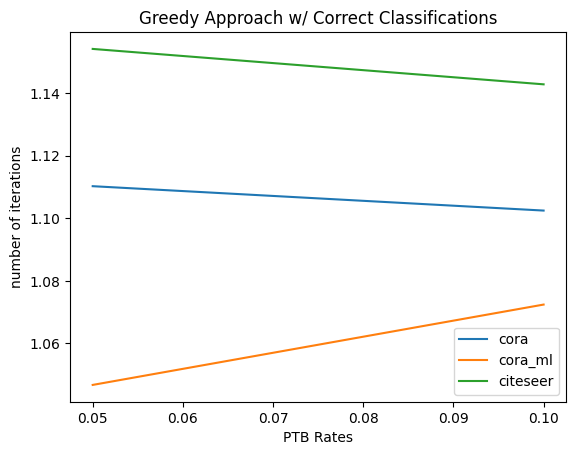

In [25]:
# Plotting
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
plt.plot(ptb_rate, results_cora, label="cora")
plt.plot(ptb_rate, results_ml, label="cora_ml")
plt.plot(ptb_rate, results_citeseer, label="citeseer")

plt.xlabel('PTB Rates')
plt.ylabel('number of iterations')
plt.title('Greedy Approach w/ Correct Classifications')
plt.legend()

output_path = f"./data/degree/greedy_w_correct_classifications.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [19]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/degree/cora/gcn_results.npy',
    f'./data-arrays/degree/cora/pubmed/cora_ml.npy',
    f'./data-arrays/degree/cora/citeseer/gcn_results.npy',
]

results = [
    np.array(results_cora),
    np.array(results_ml),
    np.array(results_citeseer),
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)